In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from pathlib import Path

print("Library berhasil di-import.")

Library berhasil di-import.


Ukuran citra: 1278 x 1600 piksel


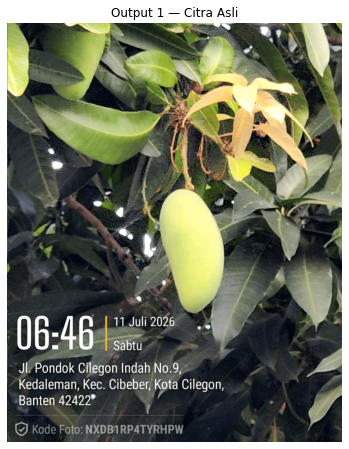

In [2]:
NAMA_FILE = "gambar_mangga.png"

citra_bgr = cv2.imread(NAMA_FILE)

if citra_bgr is None:
    raise FileNotFoundError(
        f"File {NAMA_FILE} tidak ditemukan. "
        "Pastikan gambar berada dalam folder yang sama dengan notebook."
    )

citra_rgb = cv2.cvtColor(citra_bgr, cv2.COLOR_BGR2RGB)

tinggi, lebar = citra_rgb.shape[:2]

print("Ukuran citra:", lebar, "x", tinggi, "piksel")

plt.figure(figsize=(6, 8))
plt.imshow(citra_rgb)
plt.title("Output 1 — Citra Asli")
plt.axis("off")
plt.show()

In [11]:
citra_hsv = cv2.cvtColor(
    citra_bgr,
    cv2.COLOR_BGR2HSV
)

citra_lab = cv2.cvtColor(
    citra_bgr,
    cv2.COLOR_BGR2LAB
)

print("Konversi BGR ke HSV dan LAB berhasil.")

Konversi BGR ke HSV dan LAB berhasil.


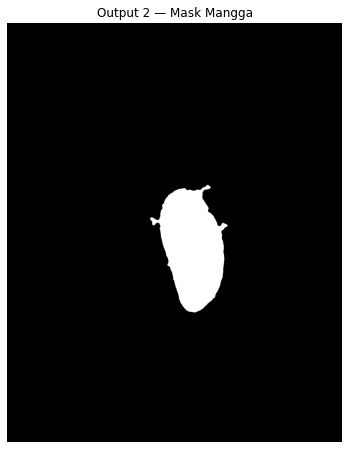

In [4]:
batas_bawah_hsv = np.array(
    [20, 25, 110],
    dtype=np.uint8
)

batas_atas_hsv = np.array(
    [45, 180, 255],
    dtype=np.uint8
)

mask_hsv_mangga = cv2.inRange(
    citra_hsv,
    batas_bawah_hsv,
    batas_atas_hsv
)

batas_bawah_lab = np.array(
    [100, 0, 145],
    dtype=np.uint8
)

batas_atas_lab = np.array(
    [255, 255, 255],
    dtype=np.uint8
)

mask_lab_mangga = cv2.inRange(
    citra_lab,
    batas_bawah_lab,
    batas_atas_lab
)

calon_mask_mangga = cv2.bitwise_and(
    mask_hsv_mangga,
    mask_lab_mangga
)

batas_pencarian = int(tinggi * 0.79)

calon_mask_mangga[
    batas_pencarian:,
    :
] = 0

kernel_open = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

kernel_close = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (15, 15)
)

calon_mask_mangga = cv2.morphologyEx(
    calon_mask_mangga,
    cv2.MORPH_OPEN,
    kernel_open
)

calon_mask_mangga = cv2.morphologyEx(
    calon_mask_mangga,
    cv2.MORPH_CLOSE,
    kernel_close
)

jumlah_label, label, statistik, titik_tengah = (
    cv2.connectedComponentsWithStats(
        calon_mask_mangga,
        connectivity=8
    )
)

label_terbaik = None
skor_terbaik = -1

for nomor_label in range(1, jumlah_label):

    x, y, w, h, luas = statistik[nomor_label]
    cx, cy = titik_tengah[nomor_label]

    if luas < 1200:
        continue

    rasio_bentuk = h / max(w, 1)

    jarak_tengah = (
        ((cx - lebar * 0.55) / (lebar * 0.55)) ** 2
        +
        ((cy - tinggi * 0.55) / (tinggi * 0.65)) ** 2
    )

    skor = float(luas) * math.exp(-jarak_tengah)

    if rasio_bentuk >= 1.2:
        skor *= 1.5 + min(rasio_bentuk, 3) / 3
    else:
        skor *= 0.15

    if cy < tinggi * 0.22:
        skor *= 0.1

    if skor > skor_terbaik:
        skor_terbaik = skor
        label_terbaik = nomor_label

if label_terbaik is None:
    raise RuntimeError(
        "Buah mangga tidak ditemukan. "
        "Sesuaikan nilai batas HSV dan LAB."
    )

mask_mangga_awal = np.zeros(
    (tinggi, lebar),
    dtype=np.uint8
)

mask_mangga_awal[
    label == label_terbaik
] = 255

kernel_buah = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (11, 11)
)

mask_mangga_awal = cv2.morphologyEx(
    mask_mangga_awal,
    cv2.MORPH_OPEN,
    kernel_buah
)

kontur, hierarchy = cv2.findContours(
    mask_mangga_awal,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

mask_mangga = np.zeros(
    (tinggi, lebar),
    dtype=np.uint8
)

if len(kontur) > 0:

    kontur_terbesar = max(
        kontur,
        key=cv2.contourArea
    )

    cv2.drawContours(
        mask_mangga,
        [kontur_terbesar],
        -1,
        255,
        thickness=-1
    )

mask_mangga = cv2.morphologyEx(
    mask_mangga,
    cv2.MORPH_CLOSE,
    cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (7, 7)
    )
)


plt.figure(figsize=(6, 8))
plt.imshow(
    mask_mangga,
    cmap="gray"
)
plt.title("Output 2 — Mask Mangga")
plt.axis("off")
plt.show()

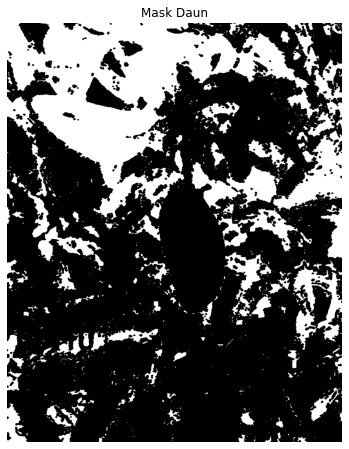

In [5]:
batas_bawah_daun = np.array(
    [32, 35, 18],
    dtype=np.uint8
)

batas_atas_daun = np.array(
    [100, 255, 255],
    dtype=np.uint8
)

mask_hijau = cv2.inRange(
    citra_hsv,
    batas_bawah_daun,
    batas_atas_daun
)

kanal_b, kanal_g, kanal_r = cv2.split(
    citra_bgr
)

excess_green = (
    2 * kanal_g.astype(np.int16)
    - kanal_r.astype(np.int16)
    - kanal_b.astype(np.int16)
)

mask_excess_green = np.where(
    excess_green > 8,
    255,
    0
).astype(np.uint8)

mask_daun = cv2.bitwise_and(
    mask_hijau,
    mask_excess_green
)

mask_mangga_dilatasi = cv2.dilate(
    mask_mangga,
    cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (9, 9)
    )
)

mask_daun = cv2.bitwise_and(
    mask_daun,
    cv2.bitwise_not(
        mask_mangga_dilatasi
    )
)

mask_daun = cv2.morphologyEx(
    mask_daun,
    cv2.MORPH_OPEN,
    cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )
)

mask_daun = cv2.morphologyEx(
    mask_daun,
    cv2.MORPH_CLOSE,
    cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (7, 7)
    )
)


plt.figure(figsize=(6, 8))
plt.imshow(
    mask_daun,
    cmap="gray"
)
plt.title("Mask Daun")
plt.axis("off")
plt.show()

In [6]:
segmentasi_daun = cv2.bitwise_and(
    citra_rgb,
    citra_rgb,
    mask=mask_daun
)

segmentasi_mangga = cv2.bitwise_and(
    citra_rgb,
    citra_rgb,
    mask=mask_mangga
)


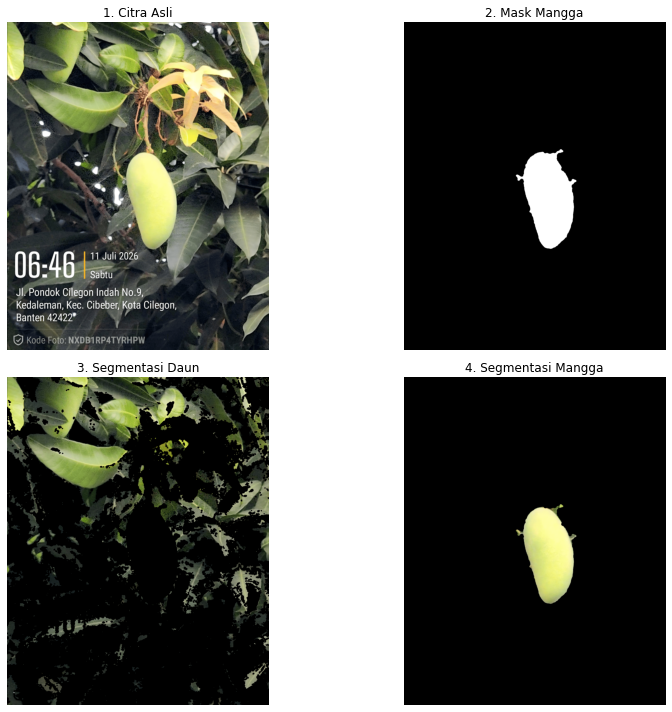

In [7]:
plt.figure(figsize=(13, 10))

plt.subplot(2, 2, 1)
plt.imshow(citra_rgb)
plt.title("1. Citra Asli")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(
    mask_mangga,
    cmap="gray"
)
plt.title("2. Mask Mangga")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(segmentasi_daun)
plt.title("3. Segmentasi Daun")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(segmentasi_mangga)
plt.title("4. Segmentasi Mangga")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
folder_output = Path("hasil_segmentasi")
folder_output.mkdir(exist_ok=True)

cv2.imwrite(
    str(folder_output / "01_citra_asli.png"),
    cv2.cvtColor(
        citra_rgb,
        cv2.COLOR_RGB2BGR
    )
)

cv2.imwrite(
    str(folder_output / "02_mask_mangga.png"),
    mask_mangga
)

cv2.imwrite(
    str(folder_output / "03_segmentasi_daun.png"),
    cv2.cvtColor(
        segmentasi_daun,
        cv2.COLOR_RGB2BGR
    )
)

cv2.imwrite(
    str(folder_output / "04_segmentasi_mangga.png"),
    cv2.cvtColor(
        segmentasi_mangga,
        cv2.COLOR_RGB2BGR
    )
)

jumlah_piksel = tinggi * lebar

luas_mangga = np.count_nonzero(
    mask_mangga
)

luas_daun = np.count_nonzero(
    mask_daun
)

persentase_mangga = (
    luas_mangga / jumlah_piksel
) * 100

persentase_daun = (
    luas_daun / jumlah_piksel
) * 100